In [5]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv("test.csv")
print(data.head())

  expense_id       user_id transaction_date  amount currency       category  \
0     EXP001  USR-3KJ8Q2ZL       2024-04-15   53.25      USD           Food   
1     EXP002  USR-9VD3M5NL       2024-02-29    0.00      USD          Other   
2     EXP003  USR-1ZB7P2XQ       2023-12-23   19.99      AUD  Entertainment   
3     EXP004  USR-7KH2R9WL       2024-04-02   86.75      EUR         Travel   
4     EXP005  USR-5CX9N4JB       2024-03-29   45.50      CAD           Food   

  subcategory                                    description  \
0  Restaurant  Business lunch at The Grove with client team.   
1      Refund         Refund for overcharged utilities bill.   
2   Streaming         Monthly Netflix subscription for home.   
3       Train       Business train ticket Berlin to Hamburg.   
4        Cafe       Coffee and pastries for morning meeting.   

       merchant_name payment_method  is_business_expense  receipt_available  \
0   The Grove Bistro    credit_card                 True     

In [8]:
data = data[['description', 'merchant_name']]
data = data.dropna()

In [9]:
data['text'] = data['description'] + " " + data['merchant_name']

In [10]:
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X = tfidf.fit_transform(data['text'])

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [12]:
data['cluster'] = kmeans.labels_

In [13]:
print(data[['text', 'cluster']].head(10))

                                                text  cluster
0  Business lunch at The Grove with client team. ...        2
1  Refund for overcharged utilities bill. Pacific...        1
2  Monthly Netflix subscription for home. Netflix...        1
3  Business train ticket Berlin to Hamburg. Deuts...        1
4  Coffee and pastries for morning meeting. Bean ...        2
5  Executive office chair for new manager. Office...        1
6  Dinner at Zurich central for personal. Zurich ...        1
7  Flight to London for conference keynote. Briti...        1
8  Karaoke night in Shibuya with friends. Karaoke...        1
9  Monthly Xfinity internet bill for apartment. X...        1


In [14]:
print(data['cluster'].value_counts())

cluster
1    168
2     22
0     10
Name: count, dtype: int64


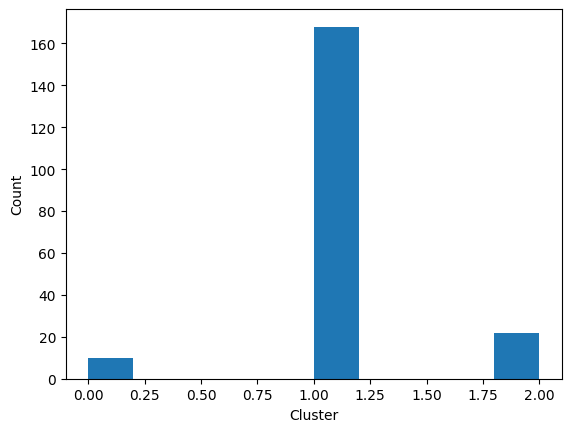

In [15]:
plt.hist(data['cluster'])
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()